# Visualize Processed TerraSAR-X Dataset

This notebook visualizes samples from the processed TerraSAR-X datasets created by the `TSX_dataset_creation.py` script. For each dataset (train, validation, test), we'll display 3 random patches showing the real part, imaginary part, and intensity components.

In [1]:
import os
import sys
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to path to import from src
sys.path.append(str(Path().resolve().parent))

# Import normalize_sar function from utils
from src.utils.sar_utils import normalize_sar, m, M

## Load HDF5 Datasets

Load the train, validation, and test datasets created by the TSX_dataset_creation.py script.

In [2]:
seed = 1

# Paths to the HDF5 datasets
data_dir = "../data/processed_hdf5/random_split_preserved_60dB"
train_path = os.path.join(data_dir, "train.h5")
val_path = os.path.join(data_dir, "val.h5")
test_path = os.path.join(data_dir, "test.h5")

# Check if files exist
for path in [train_path, val_path, test_path]:
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist!")

# Load datasets
train_data = h5py.File(train_path, "r")
val_data = h5py.File(val_path, "r")
test_data = h5py.File(test_path, "r")

print(f"Train dataset shape: {train_data['patches'].shape}")
print(f"Validation dataset shape: {val_data['patches'].shape}")
print(f"Test dataset shape: {test_data['patches'].shape}")

Train dataset shape: (27836, 256, 256, 2)
Validation dataset shape: (3478, 256, 256, 2)
Test dataset shape: (3483, 256, 256, 2)


## Print Dataset Attributes

Display the metadata attributes stored in the HDF5 files.

In [3]:
# Print dataset attributes
print("Train dataset attributes:")
for key, value in train_data.attrs.items():
    print(f"  {key}: {value}")

# Note the 5th and 95th percentile values used for normalization
p5 = train_data.attrs["p5"]
p95 = train_data.attrs["p95"]
print(f"\nNormalization range for log-intensity:")
print(f"  m (5th percentile) = {m} dB")
print(f"  M (95th percentile) = {M} dB")

Train dataset attributes:
  creation_date: 2025-04-30 11:09:00.609727
  mean: 40.41421127319336
  median: 41.06836700439453
  num_patches: 27836
  p1: 20.969100952148438
  p10: 31.498353958129883
  p5: 28.175657272338867
  p90: 48.52882385253906
  p95: 50.47134780883789
  p99: 54.32472229003906
  patch_size: 256

Normalization range for log-intensity:
  m (5th percentile) = 28.17565727233887 dB
  M (95th percentile) = 50.32925033569336 dB


## Create Visualization Function

Define a function to visualize random samples from a dataset.

In [4]:
def visualize_random_patches(dataset, num_patches=3, seed=42):
    """
    Visualize random patches from the dataset.

    Args:
        dataset: HDF5 dataset containing patches
        num_patches: Number of random patches to visualize
        seed: Random seed for reproducibility
    """
    # Set seed for reproducibility
    random.seed(seed)

    # Get dataset size
    n_samples = dataset["patches"].shape[0]

    # Select random indices
    indices = random.sample(range(n_samples), num_patches)

    # Create figure
    fig, axes = plt.subplots(num_patches, 3, figsize=(15, 5 * num_patches))

    # For each random patch
    for i, idx in enumerate(indices):
        # Get the patch
        patch = dataset["patches"][idx]

        # Extract real and imaginary components (already squared from processing)
        real_part = patch[:, :, 0]
        imag_part = patch[:, :, 1]

        # Calculate intensity (sum of squared real and imaginary parts)

        # Apply normalization for visualization
        real_norm = normalize_sar(real_part)
        imag_norm = normalize_sar(imag_part)
        intensity_norm = real_norm + imag_norm

        # Plot real part
        im0 = axes[i, 0].imshow(real_norm, cmap="gray")
        axes[i, 0].set_title(f"Real Part (Squared) - Patch {idx}")
        axes[i, 0].axis("off")
        fig.colorbar(im0, ax=axes[i, 0], shrink=0.7)

        # Plot imaginary part
        im1 = axes[i, 1].imshow(imag_norm, cmap="gray")
        axes[i, 1].set_title(f"Imaginary Part (Squared) - Patch {idx}")
        axes[i, 1].axis("off")
        fig.colorbar(im1, ax=axes[i, 1], shrink=0.7)

        # Plot intensity
        im2 = axes[i, 2].imshow(intensity_norm, cmap="gray")
        axes[i, 2].set_title(f"Intensity - Patch {idx}")
        axes[i, 2].axis("off")
        fig.colorbar(im2, ax=axes[i, 2], shrink=0.7)

    plt.tight_layout()
    return fig

## Visualize Training Dataset Samples

Display 3 random samples from the training dataset.

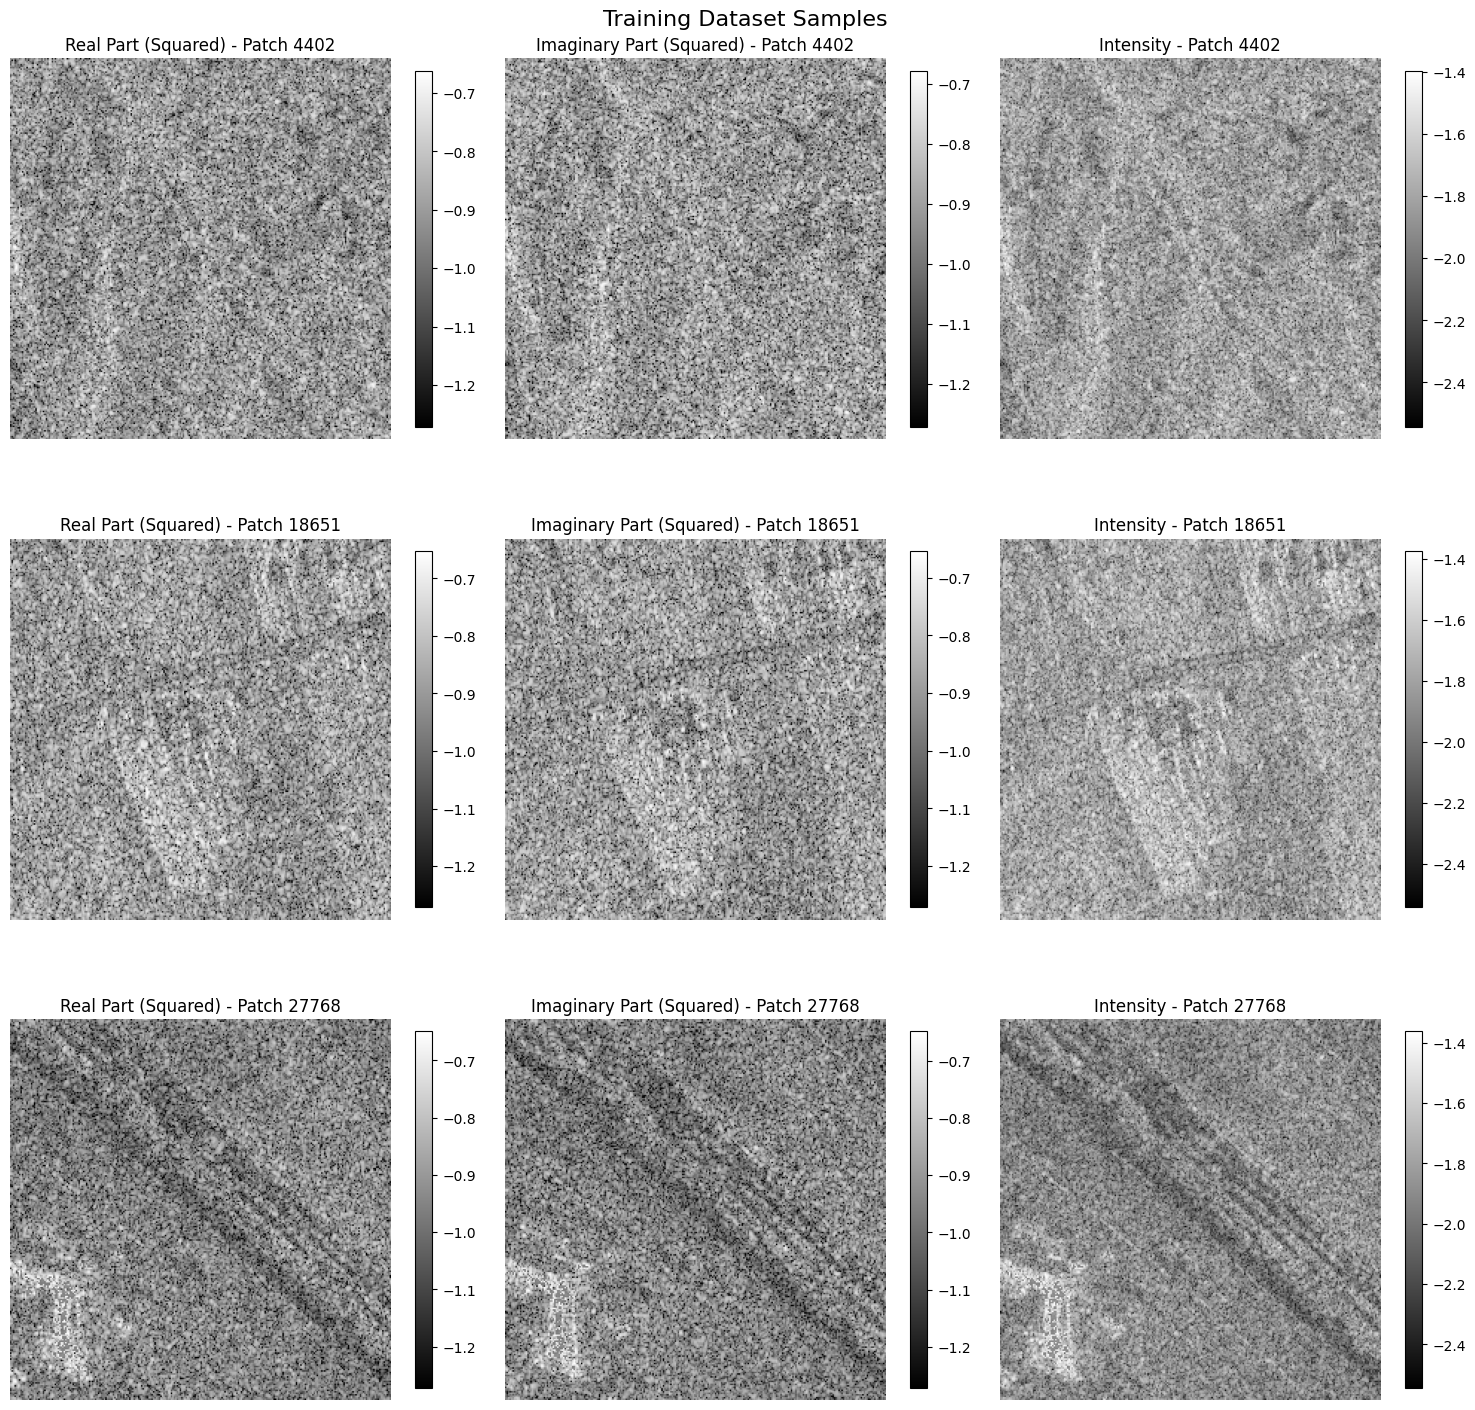

In [5]:
# Set different seeds for each dataset to get different samples
fig_train = visualize_random_patches(train_data, num_patches=3, seed=seed)
plt.suptitle("Training Dataset Samples", fontsize=16)
plt.show()

## Visualize Validation Dataset Samples

Display 3 random samples from the validation dataset.

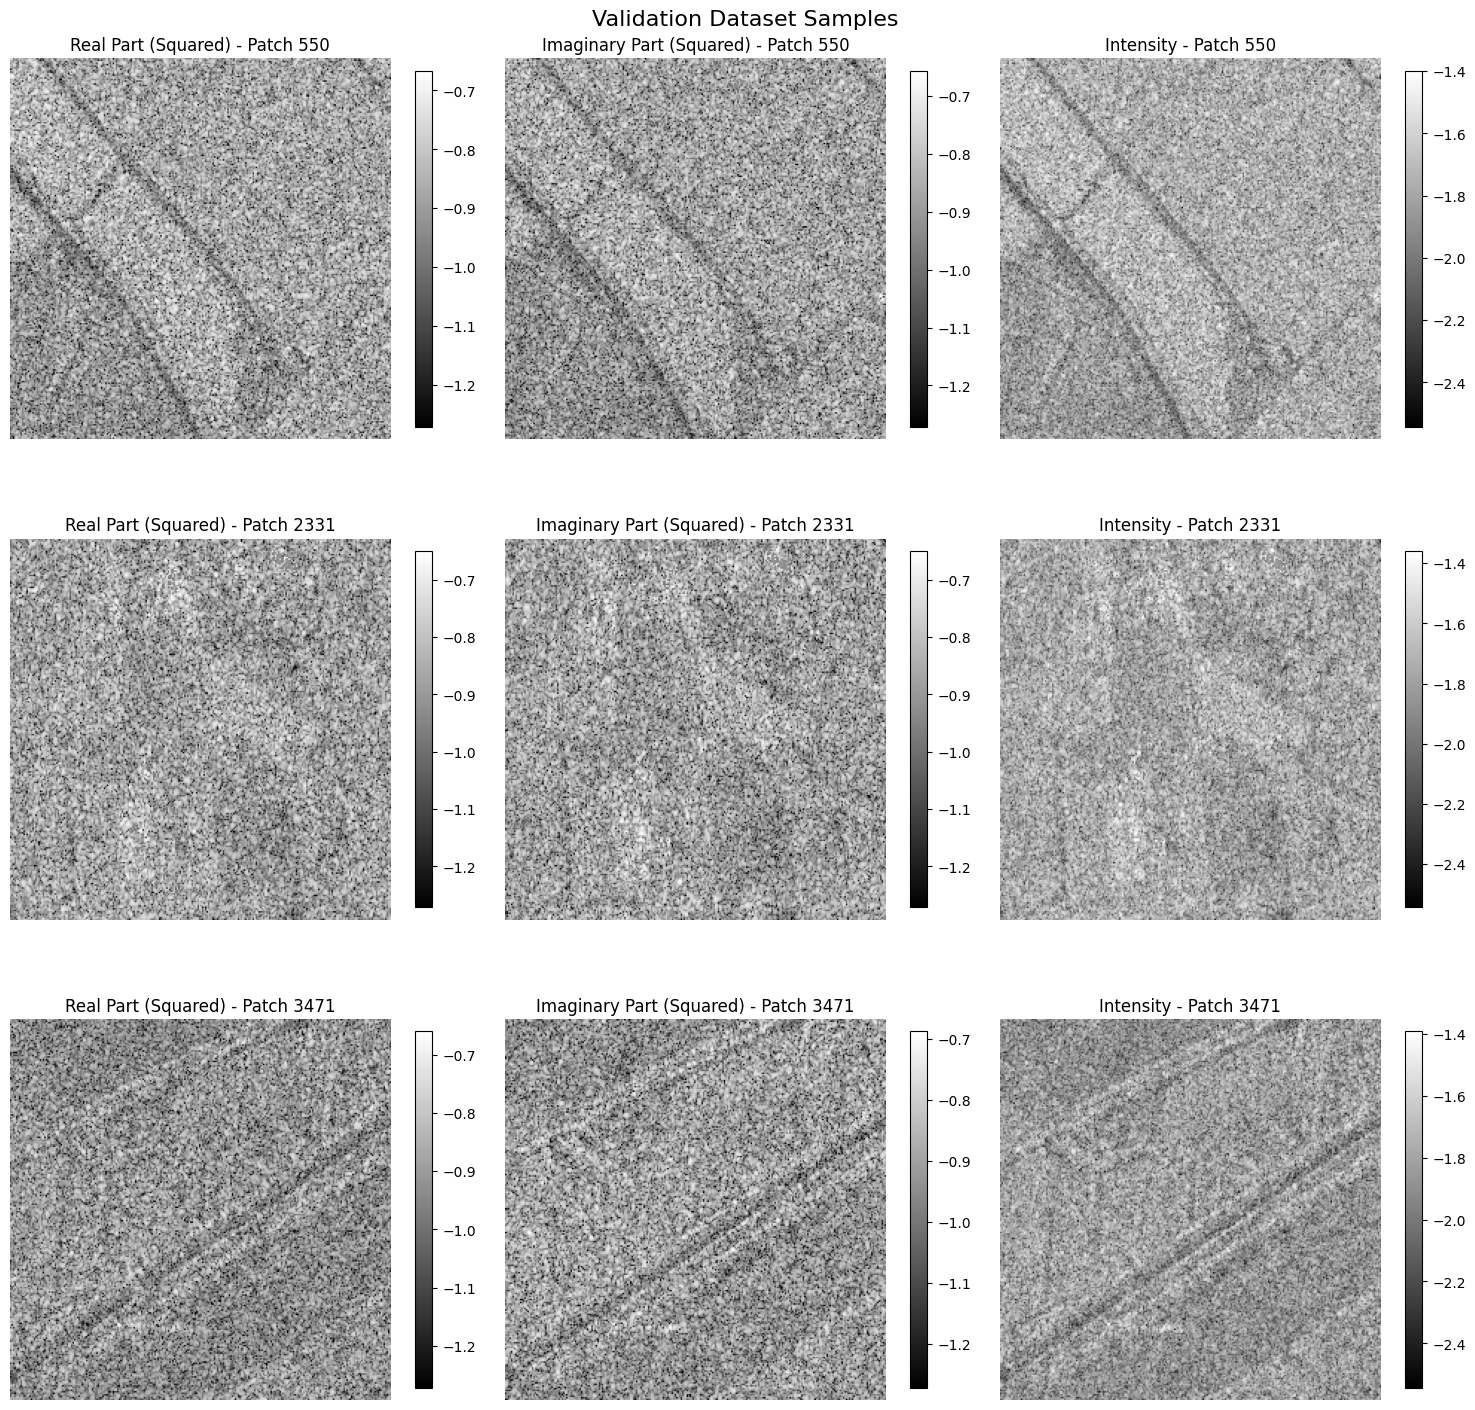

In [6]:
fig_val = visualize_random_patches(val_data, num_patches=3, seed=seed)
plt.suptitle("Validation Dataset Samples", fontsize=16)
plt.show()

## Visualize Test Dataset Samples

Display 3 random samples from the test dataset.

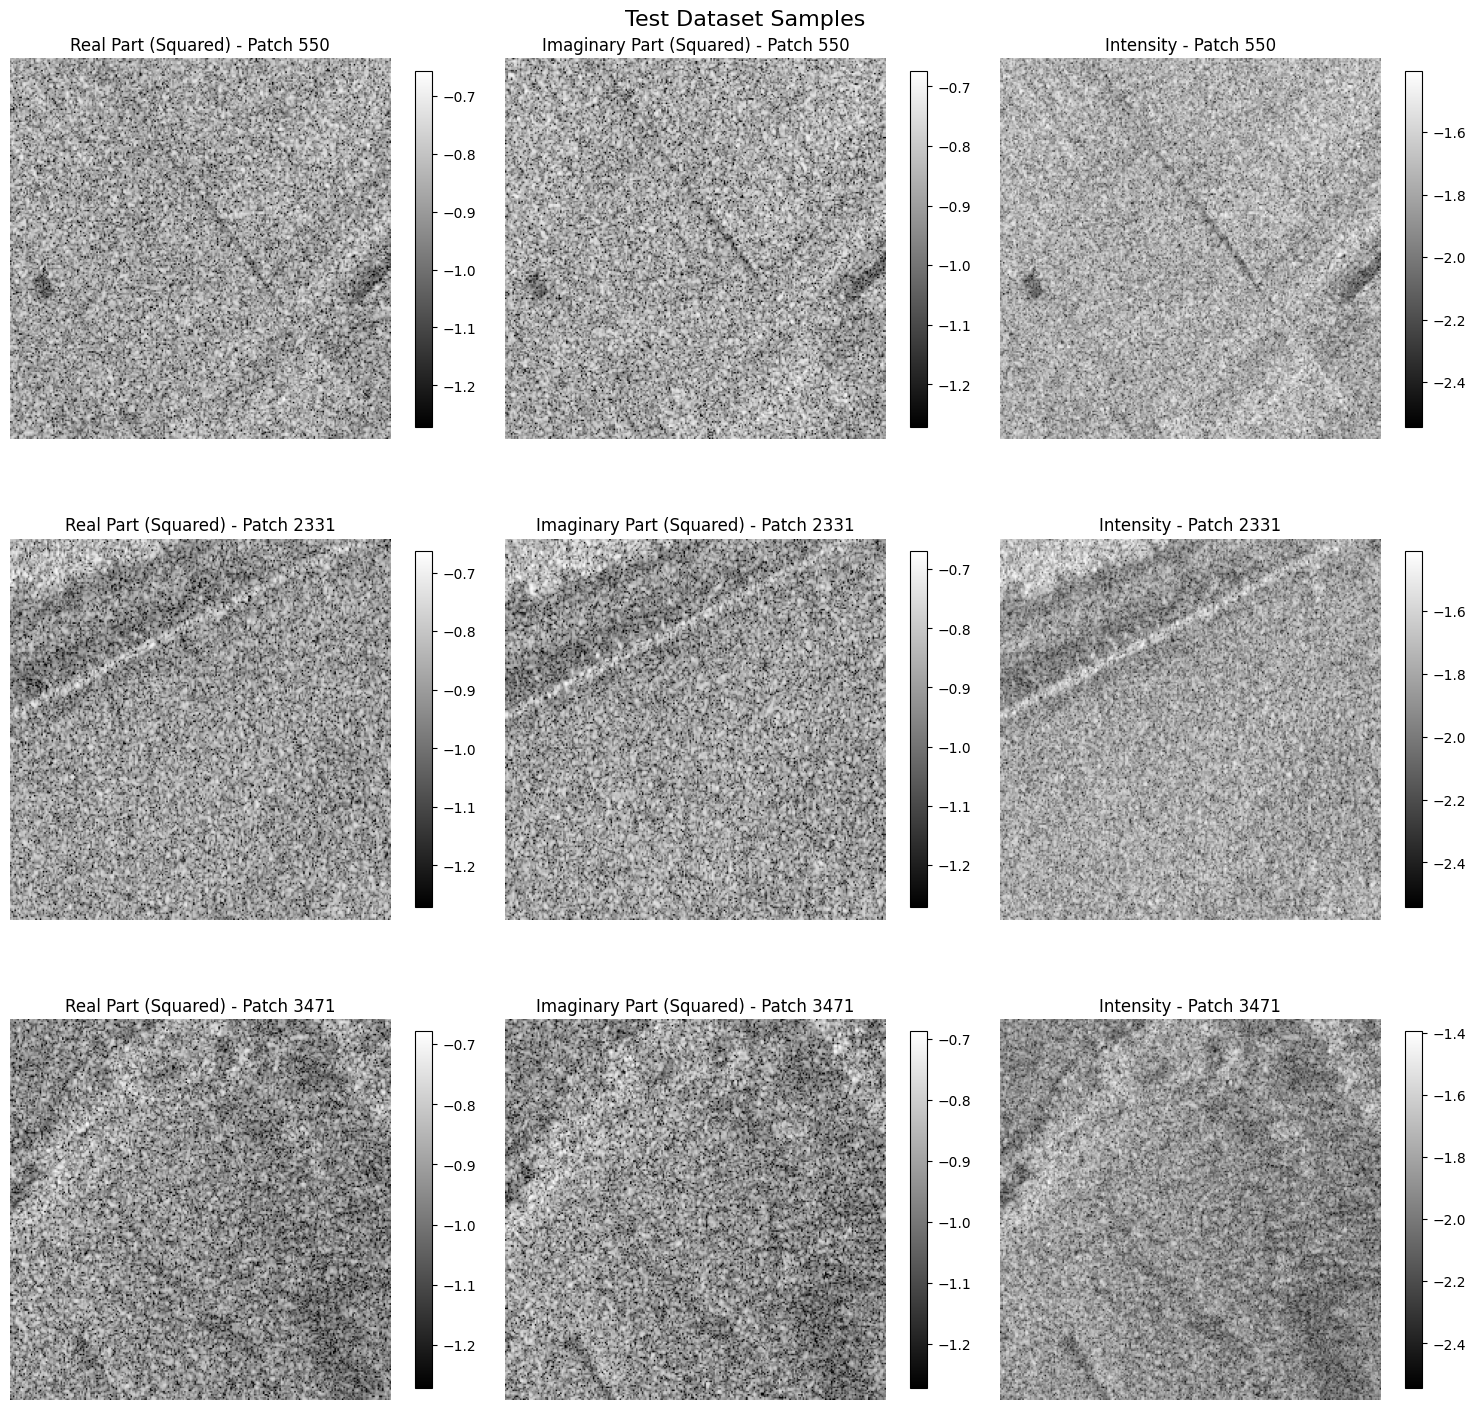

In [7]:
fig_test = visualize_random_patches(test_data, num_patches=3, seed=seed)
plt.suptitle("Test Dataset Samples", fontsize=16)
plt.show()

## Observations

The visualizations above show random patches from the processed TerraSAR-X dataset. Each row represents a different patch, and the columns show:

1. **Left Column**: Real part (squared) - Shows the squared real component of the SAR data
2. **Middle Column**: Imaginary part (squared) - Shows the squared imaginary component of the SAR data
3. **Right Column**: Intensity - Sum of squared real and imaginary parts

All images are normalized using the `normalize_sar()` function which applies a log transform and normalizes using predetermined 5th and 95th percentile values:
- 5th percentile: 28.17565727233887 dB
- 95th percentile: 50.32925033569336 dB

The dataset contains processed SAR data where:
- The real and imaginary parts have been symmetrized to ensure proper zero-Doppler centering
- The values are already squared in both real and imaginary channels
- Point-like scatterers have been preserved during processing

In [8]:
# Close the HDF5 files
train_data.close()
val_data.close()
test_data.close()

print("HDF5 files closed successfully.")

HDF5 files closed successfully.
